In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
folders=os.listdir('/content/drive/MyDrive/brain tumor/')
print(folders)

['yes', 'no']


In [3]:
for f in folders:
  path = '/content/drive/MyDrive/brain tumor/' + f

  print(f+" " + str(len(os.listdir(path))))

yes 155
no 98


In [4]:
import keras.utils as image
import matplotlib.pyplot as plt

In [5]:
sample_image = '/content/drive/MyDrive/brain tumor/no/10 no.jpg'
img = image.load_img(sample_image)
print(type(img))


<class 'PIL.JpegImagePlugin.JpegImageFile'>


In [6]:
img = image.img_to_array(img)/255.0
print(img.shape)


(201, 173, 3)


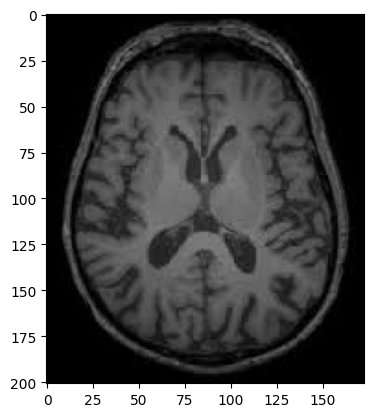

In [7]:
plt.imshow(img)
plt.show()

In [8]:
from keras.preprocessing.image import ImageDataGenerator

In [9]:
train_gen = ImageDataGenerator(rescale = 1.0/255)

train_generator = train_gen.flow_from_directory('/content/drive/MyDrive/brain tumor/',
                                                target_size = (224,224),#
                                                batch_size = 32,
                                                class_mode = 'categorical')

Found 253 images belonging to 2 classes.


In [10]:
for x, y in train_generator:
  x, y = train_generator.next()
  print(x.shape, y.shape)
  break

(32, 224, 224, 3) (32, 2)


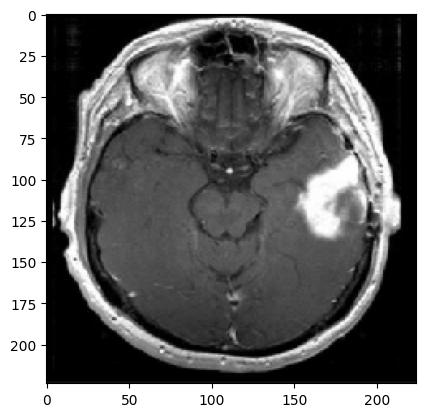

[0. 1.]


In [11]:
plt.imshow(x[10])
plt.show()
print(y[10])

In [12]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
import numpy as np

In [13]:
base_model = ResNet50(weights = 'imagenet', include_top = False, input_shape=(174, 174, 3))#??
base_model.summary()


94765736/94765736 [==============================] - 0s 0us/step
Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 174, 174, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 180, 180, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 87, 87, 64)   9472        ['conv1_pad[0][0]']              
                                                                                                  
 conv1_bn (BatchNormalizat

In [20]:
for layer in base_model.layers:
  layer.trainable = True

In [21]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(2, activation = 'softmax')(x)

In [22]:
model = Model(inputs = base_model.input, outputs = x)

In [23]:
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 174, 174, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 180, 180, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 87, 87, 64)   9472        ['conv1_pad[0][0]']              
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 87, 87, 64)   256         ['conv1_conv[0][0]']       

In [26]:
from tensorflow.keras import optimizers
model.compile(loss = 'binary_crossentropy', optimizer = "adam", metrics=["accuracy"])

In [27]:
history = model.fit_generator(
    train_generator,
    epochs = 100,
    steps_per_epoch = 7
  )

<ipython-input-27-f51ab8362f49>:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(


Epoch 1/100
7/7 [==============================] - 128s 16s/step - loss: 0.5087 - accuracy: 0.8462
Epoch 2/100
7/7 [==============================] - 110s 16s/step - loss: 0.7692 - accuracy: 0.8281
Epoch 3/100
7/7 [==============================] - 110s 16s/step - loss: 0.5471 - accuracy: 0.8100
Epoch 4/100
7/7 [==============================] - 112s 16s/step - loss: 0.4397 - accuracy: 0.8462
Epoch 5/100
7/7 [==============================] - 114s 16s/step - loss: 0.2416 - accuracy: 0.9095
Epoch 6/100
7/7 [==============================] - 112s 16s/step - loss: 0.1211 - accuracy: 0.9638
Epoch 7/100
7/7 [==============================] - 112s 16s/step - loss: 0.0674 - accuracy: 0.9777
Epoch 8/100
7/7 [==============================] - 112s 16s/step - loss: 0.0468 - accuracy: 0.9819
Epoch 9/100
7/7 [==============================] - 114s 16s/step - loss: 0.0171 - accuracy: 0.9955
Epoch 10/100
7/7 [==============================] - 114s 16s/step - loss: 0.0181 - accuracy: 0.9910
Epoch 11/

KeyboardInterrupt: ignored